# Few-Shot with a RidgeClassifier
Creates a model that combines pybioclip image embeddings with a RidgeClassifier using images from the [Somnath01/Birds_Species](https://huggingface.co/datasets/Somnath01/Birds_Species) dataset. This dataset contains 1000 train images, 403 test images, and 50 validation images. This notebook only uses the train and test images. This dataset was chosen for convenience. No analysis of the suitability of this dataset has been done.

When running this notebook in COLAB change the _runtime type_ to a GPU type to speed up processing. Additionally when running the next step in COLAB you you may see an error about the version of `fsspec` installed. This issue doesn't seem to cause any problem with this notebook.

In [ ]:
!pip install -q numpy datasets pybioclip scikit-learn matplotlib

In [1]:
import itertools
import numpy as np
from tqdm.notebook import tqdm

import torch
from datasets import load_dataset

from bioclip.predict import BaseClassifier

import sklearn.model_selection
import sklearn.pipeline
import sklearn.preprocessing
import sklearn.experimental.enable_halving_search_cv
import sklearn.linear_model
import scipy.stats
from sklearn.preprocessing import FunctionTransformer

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Dataset settings
HF_DATASET_NAME = "Somnath01/Birds_Species"
TRAIN_NAME = 'train'
TEST_NAME = 'test'
IMAGE_NAME = 'image'
LABEL_NAME = 'label'

# Image embedding settings
BATCH_SIZE = 30

## Determine GPU or CPU

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


## Load dataset
This step takes around 7 minutes to download the images the first time it is run.

### Setting up HF_TOKEN (Recommended for Google Colab)

You may see warnings `The secret 'HF_TOKEN' does not exist in your Colab secrets.` when running the code block below. To avoid rate limiting errors when running in Google Colab, follow these steps to set up your HuggingFace token:

1. **Create a HuggingFace account and token:**
   - Go to [https://huggingface.co/](https://huggingface.co/) and create an account if you don't have one
   - Navigate to your [Access Tokens page](https://huggingface.co/settings/tokens)
   - Click "New token" and create a token with "Read" permissions
   - Copy the generated token

2. **Add the token as a Colab secret:**
   - In Google Colab, click the key icon (🔑) in the left sidebar to open the Secrets panel
   - Click "Add new secret"
   - Set the name to `HF_TOKEN`
   - Paste your HuggingFace token as the value
   - Click "Add secret"

3. **Grant notebook access to the secret:**
   - In the Secrets panel, find your `HF_TOKEN` secret
   - Toggle the switch next to the notebook name to grant access
   - The switch should turn blue/green when enabled

After setting up the token, restart your runtime (Runtime → Restart runtime) and re-run the cells above before proceeding.

In [4]:
dataset = load_dataset(HF_DATASET_NAME)
dataset

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/403 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 50
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 403
    })
})

Labels: ABBOTTS BABBLER,ABBOTTS BOOBY,ABYSSINIAN GROUND HORNBILL,AFRICAN CROWNED CRANE,AFRICAN EMERALD CUCKOO,AFRICAN FIREFINCH,AFRICAN OYSTER CATCHER,AFRICAN PIED HORNBILL,AFRICAN PYGMY GOOSE,ALBATROSS 

Example Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x133D310A0>


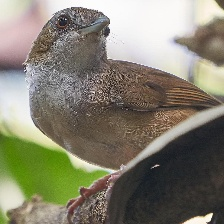

In [5]:
print("Labels:", ",".join(dataset[TRAIN_NAME].features[LABEL_NAME].names), "\n")
print("Example Image:", dataset[TRAIN_NAME][IMAGE_NAME][0])
dataset[TRAIN_NAME][IMAGE_NAME][0]

## Function to Convert PIL to image embeddings

In [6]:
classifier = BaseClassifier(device=device)

In [7]:
def batched(items, batch_size):
    it = iter(items)
    while (batch := list(itertools.islice(it, batch_size))):
          yield batch

In [8]:
def create_image_features(pil_image_ary):
    # batch PIL -> features transformation
    all_features = []
    with tqdm(total=len(pil_image_ary), desc='Creating image embeddings', unit='image') as progress_bar:
        for images in batched(pil_image_ary, BATCH_SIZE):
            features = classifier.create_image_features(images, normalize=True)
            all_features.append(features.cpu())
            progress_bar.update(len(images))
    return torch.cat(all_features, dim=0).cpu().numpy()

## Function to show prediction metrics

In [9]:
def show_metrics(expected_label_ary, predicted_label_ary):
    print("Accuracy:", round(accuracy_score(expected_label_ary, predicted_label_ary), 3))
    cm = confusion_matrix(expected_label_ary, predicted_label_ary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title("Confusion Matrix")
    plt.show()

## Setup a RidgeClassifier model
The `init_clf()` function is simplfied from [biobench plantnet](https://github.com/samuelstevens/biobench/blob/637432bfda2b567d966d49bf8c4b37b339d4dc2a/biobench/plantnet/__init__.py#L212C1-L228C6) 
created by [@samuelstevens](https://github.com/samuelstevens).

In [10]:
def init_clf():
    return sklearn.pipeline.make_pipeline(
            sklearn.preprocessing.StandardScaler(),
            sklearn.linear_model.RidgeClassifier(),
        )

In [11]:
# Create a model that preprocesses images into feature embeddings that are passed to the RidgeClassifier
model = sklearn.pipeline.make_pipeline(
    FunctionTransformer(create_image_features),
    init_clf(),
)

## Train the RidgeClassifier model
Trains the model using the train dataset. This step takes ~ 8 minutes when running on CPU and ~1 minute otherwise.

In [12]:
# Convert dataset columns to lists for Colab compatibility (sklearn requires list-like objects)
model.fit(list(dataset[TRAIN_NAME][IMAGE_NAME]), list(dataset[TRAIN_NAME][LABEL_NAME]))

Creating image embeddings:   0%|          | 0/1000 [00:00<?, ?image/s]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('functiontransformer', ...), ('pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...t 0x138fb09a0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword argument

## Create predictions
Predicts species for the test dataset. This step takes ~ 4 minutes when running on CPU and ~1 minute otherwise.

Creating image embeddings:   0%|          | 0/403 [00:00<?, ?image/s]

Accuracy: 0.998


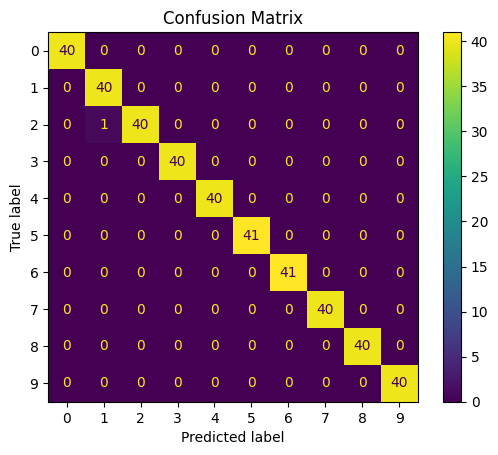

In [13]:
# Convert dataset columns to lists for Colab compatibility (sklearn requires list-like objects)
predicted_labels = model.predict(list(dataset[TEST_NAME][IMAGE_NAME]))
show_metrics(predicted_labels, list(dataset[TEST_NAME][LABEL_NAME]))

## Compare against direct zero-shot pybioclip predictions
This step takes ~ 6 minutes when running on CPU and ~1 minute otherwise.

100%|██████████| 13/13 [00:01<00:00, 10.92images/s]

Accuracy: 0.985


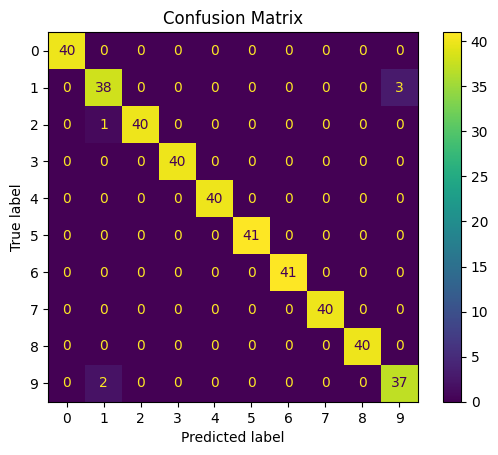

In [14]:
from bioclip.predict import CustomLabelsClassifier
classifier = CustomLabelsClassifier(dataset[TEST_NAME].features[LABEL_NAME].names, device=device)
predicted_labels = []
# Convert dataset columns to lists for Colab compatibility
for images in batched(list(dataset[TEST_NAME][IMAGE_NAME]), BATCH_SIZE):
    predictions = classifier.predict(images, k=1)
    for pred in predictions:
        label_str = pred['classification']
        label = dataset[TEST_NAME].features[LABEL_NAME].str2int(label_str)
        predicted_labels.append(label)
# Convert dataset columns to lists for Colab compatibility
show_metrics(predicted_labels, list(dataset[TEST_NAME][LABEL_NAME]))